In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [4]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [7]:

sql = f"""
select * from tmp1.stckln_amz_mattress_ms_trend 
"""

df = bqclient.query(sql).to_dataframe()

In [9]:
df

,RetailerSku,category,subcategory,profile,size,bsr_ctgry_label,Brand_raw,Brand_adj,Title,WeekEnding,RetailSales,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month
0,B0DP6C3L9J,OTHERS,OTHERS,None,None,01. Mattresses,CALVANA,CALVANA,"(2-Pack) 14.5"" Extra Long Mattress Lifter for ...",2025-03-01,443.10,35,12.66,25-1,25-02,Y25 W09,Y25 W09,3501.03,3501.03
1,B0DP6C3L9J,OTHERS,OTHERS,None,None,01. Mattresses,CALVANA,CALVANA,"(2-Pack) 14.5"" Extra Long Mattress Lifter for ...",2025-03-22,129.90,10,12.99,25-1,25-03,Y25 W12,Y25 W12,3501.03,3501.03
2,B0DP6C3L9J,OTHERS,OTHERS,None,None,01. Mattresses,CALVANA,CALVANA,"(2-Pack) 14.5"" Extra Long Mattress Lifter for ...",2025-02-15,87.92,8,10.99,25-1,25-02,Y25 W07,Y25 W07,3501.03,3501.03
3,B0DP6C3L9J,OTHERS,OTHERS,None,None,01. Mattresses,CALVANA,CALVANA,"(2-Pack) 14.5"" Extra Long Mattress Lifter for ...",2025-03-08,272.79,21,12.99,25-1,25-03,Y25 W10,Y25 W10,3501.03,3501.03
4,B0DP6C3L9J,OTHERS,OTHERS,None,None,01. Mattresses,CALVANA,CALVANA,"(2-Pack) 14.5"" Extra Long Mattress Lifter for ...",2025-02-22,263.76,24,10.99,25-1,25-02,Y25 W08,Y25 W08,3501.03,3501.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127886,B0BWT91JQ3,Foam Mattress,Cooling/Gel,8,Queen,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Queen Mattresses, Memory Foam Mattress...",2025-07-05,139.99,1,139.99,25-3,25-07,Y25 W27,Latest Week,2862281.93,38397.37
127887,B0BVZK5S5N,Foam Mattress,Cooling/Gel,6,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Mattress, 6 inch Twin Mattresses ...",2025-07-05,119.99,1,119.99,25-3,25-07,Y25 W27,Latest Week,2862281.93,38397.37
127888,B0C39RDM75,Foam Mattress,Cooling/Gel,6,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Mattress, 6 inch Twin Size Memory...",2025-07-05,109.99,1,109.99,25-3,25-07,Y25 W27,Latest Week,2862281.93,38397.37
127889,B01DOQ7E8W,OTHERS,OTHERS,None,None,01. Mattresses,PREMIER SLEEP PRODUCTS,PREMIER SLEEP PRODUCTS,"with A 8 INCH Short Queen (60"" x 75"") New Cool...",2025-07-05,430.00,1,430.00,25-3,25-07,Y25 W27,Latest Week,2455474.93,5338.79


In [11]:
df['RetailerSku'].nunique()

12737

In [13]:
df.to_csv("data_0715.csv", index=False)

### 데이터 탐색

### 2025년 Amazon Mattress 카테고리 Data 분석

In [15]:
df = pd.read_csv('data_0715.csv')

In [17]:
print(df)

       RetailerSku       category  subcategory  profile   size  \
0       B0DP6C3L9J         OTHERS       OTHERS      NaN    NaN   
1       B0DP6C3L9J         OTHERS       OTHERS      NaN    NaN   
2       B0DP6C3L9J         OTHERS       OTHERS      NaN    NaN   
3       B0DP6C3L9J         OTHERS       OTHERS      NaN    NaN   
4       B0DP6C3L9J         OTHERS       OTHERS      NaN    NaN   
...            ...            ...          ...      ...    ...   
127886  B0BWT91JQ3  Foam Mattress  Cooling/Gel      8.0  Queen   
127887  B0BVZK5S5N  Foam Mattress  Cooling/Gel      6.0   Twin   
127888  B0C39RDM75  Foam Mattress  Cooling/Gel      6.0   Twin   
127889  B01DOQ7E8W         OTHERS       OTHERS      NaN    NaN   
127890  B09N6LVKX7         OTHERS       OTHERS      NaN    NaN   

       bsr_ctgry_label               Brand_raw               Brand_adj  \
0       01. Mattresses                 CALVANA                 CALVANA   
1       01. Mattresses                 CALVANA             

### 1. 기초 통계

#### 1.1 몇 개의 ASIN이 있나요?

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [23]:
df['RetailerSku'].nunique() 

12737

In [25]:
df['Brand_raw'].nunique()

619

In [29]:
df.groupby(['category', 'subcategory'])['Brand_raw'].nunique().reset_index(name='brand_count')

,category,subcategory,brand_count
0,Foam Mattress,Cooling/Gel,214
1,Foam Mattress,Non-Cooling,173
2,OTHERS,OTHERS,464
3,Spring Mattress,Bonnell,47
4,Spring Mattress,Pocket Spring,256


In [39]:
df.groupby('Brand_raw')['RetailSales'].sum().reset_index().rename(columns={'RetailSales': 'total_sales'}).sort_values('total_sales', ascending=False)

,Brand_raw,total_sales
610,ZINUS,1.401663e+08
386,NOVILLA,6.276125e+07
168,FDW,3.963378e+07
352,MLILY,3.545190e+07
375,NECTAR,3.312092e+07
...,...,...
547,THINMAY,4.999000e+01
217,HOKWAY,4.999000e+01
324,MASTERMARK,4.299000e+01
90,COCOARM,3.412000e+01


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

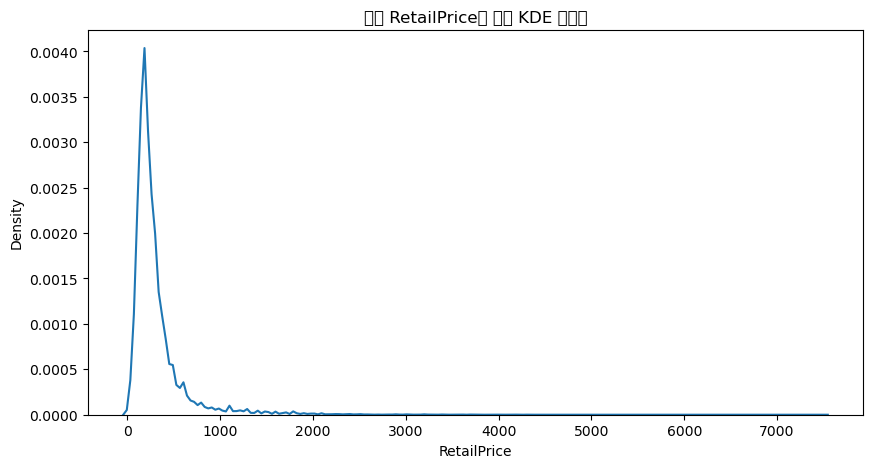

In [43]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df['RetailPrice'].dropna(), bw_adjust=0.5)  # 결측값 제거, bandwidth 조정(선택)
plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('전체 RetailPrice에 대한 KDE 그래프')
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

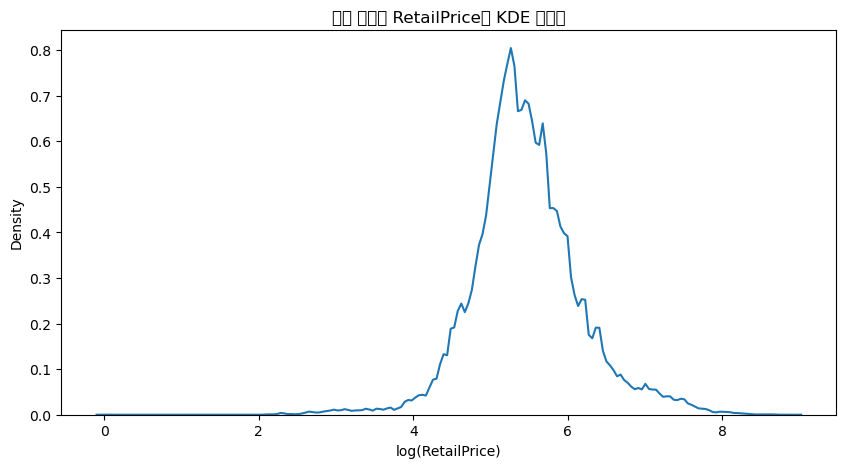

In [45]:

# 0 이하 값은 로그 변환 불가 → 0 이상만 남김
price = df['RetailPrice'].dropna()
price = price[price > 0]
log_price = np.log(price)

plt.figure(figsize=(10, 5))
sns.kdeplot(log_price, bw_adjust=0.5)
plt.xlabel('log(RetailPrice)')
plt.ylabel('Density')
plt.title('로그 변환된 RetailPrice의 KDE 그래프')
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3967339611.py:14: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3967339611.py:14: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3967339611.py:14: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3967339611.py:14: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3967339611.py:14: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3967339611.py:14: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) 

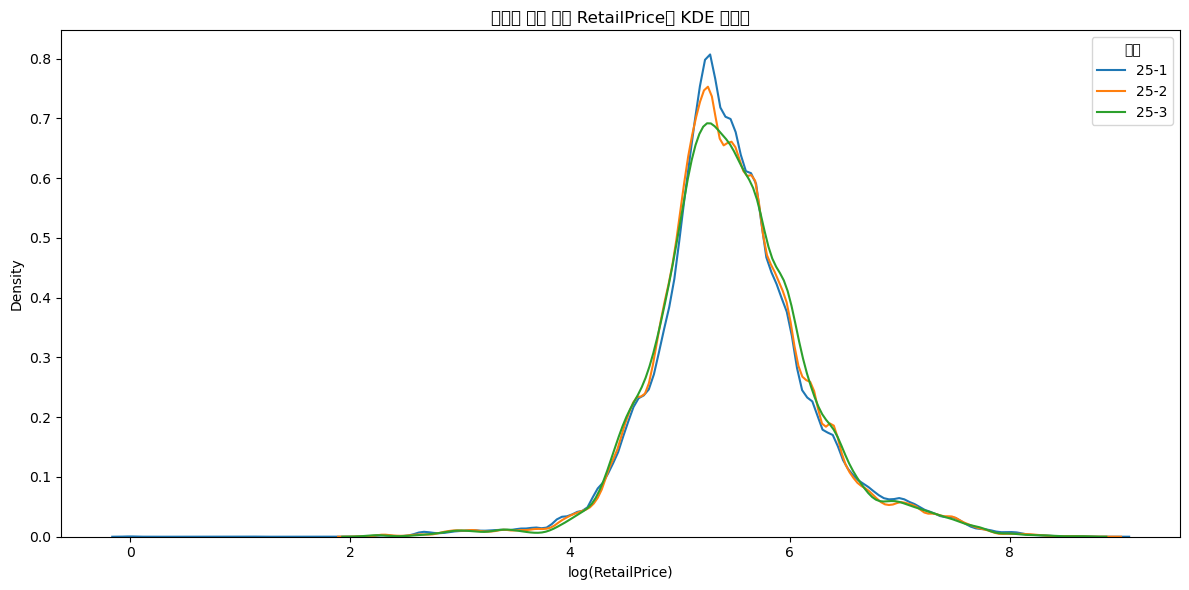

In [47]:
plt.figure(figsize=(12, 6))

# 분기별 반복
for quarter, group in df.groupby('yr_quarter'):
    prices = group['RetailPrice'].dropna()
    prices = prices[prices > 0]
    log_prices = np.log(prices)
    sns.kdeplot(log_prices, label=quarter, bw_adjust=0.7)

plt.xlabel('log(RetailPrice)')
plt.ylabel('Density')
plt.title('분기별 로그 변환 RetailPrice의 KDE 그래프')
plt.legend(title='분기')
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3802619052.py:15: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3802619052.py:15: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3802619052.py:15: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3802619052.py:15: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3802619052.py:15: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3802619052.py:15: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s)

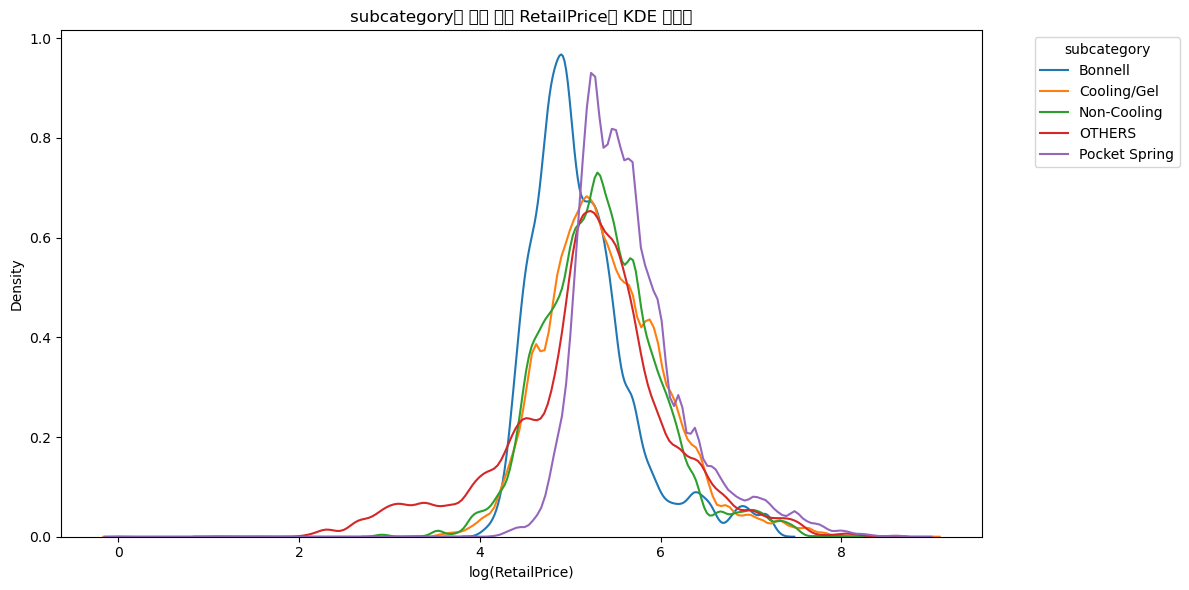

In [57]:
plt.figure(figsize=(12, 6))

# subcategory별 반복
for subcat, group in df.groupby('subcategory'):
    prices = group['RetailPrice'].dropna()
    prices = prices[prices > 0]
    log_prices = np.log(prices)
    if len(log_prices) > 1:  # 2개 이상일 때만 KDE
        sns.kdeplot(log_prices, label=subcat, bw_adjust=0.7)

plt.xlabel('log(RetailPrice)')
plt.ylabel('Density')
plt.title('subcategory별 로그 변환 RetailPrice의 KDE 그래프')
plt.legend(title='subcategory', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\1274881003.py:27: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\1274881003.py:27: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\1274881003.py:27: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\1274881003.py:27: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\1274881003.py:27: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\1274881003.py:27: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) De

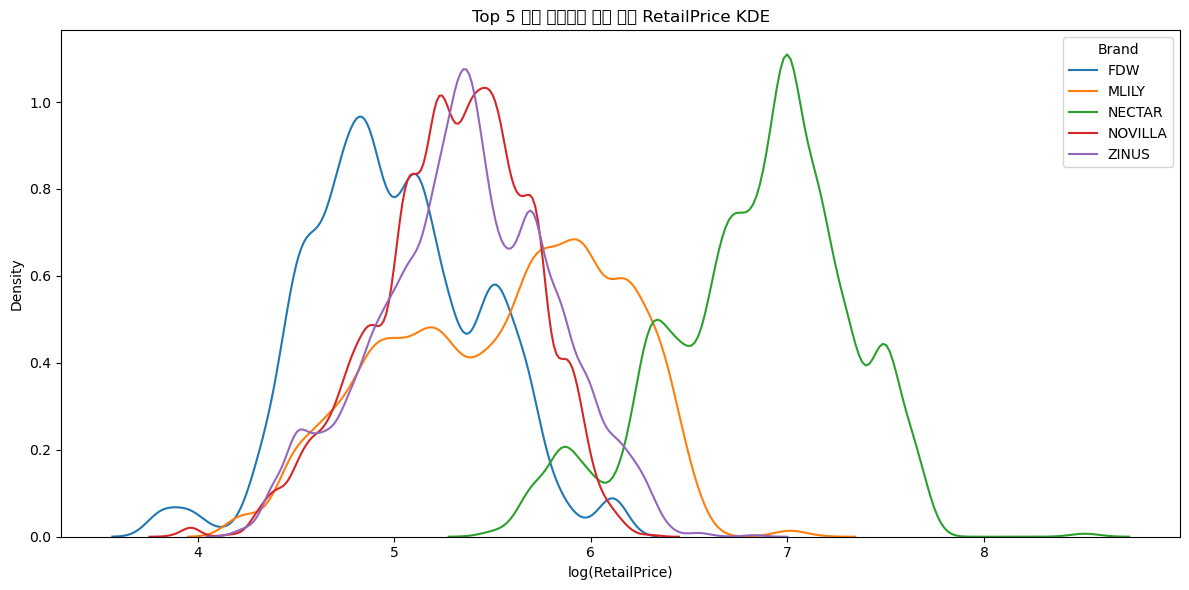

In [59]:
# 1. 브랜드별 매출 합계 집계
top5_brands = (
    df.groupby('Brand_raw')['RetailSales']
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

# 2. Top 5 브랜드의 데이터만 선택
df_top5 = df[df['Brand_raw'].isin(top5_brands)]

# 3. 브랜드별로 로그변환된 가격 KDE plot
plt.figure(figsize=(12, 6))

for brand, group in df_top5.groupby('Brand_raw'):
    prices = group['RetailPrice'].dropna()
    prices = prices[prices > 0]
    log_prices = np.log(prices)
    if len(log_prices) > 1:
        sns.kdeplot(log_prices, label=brand, bw_adjust=0.7)

plt.xlabel('log(RetailPrice)')
plt.ylabel('Density')
plt.title('Top 5 매출 브랜드의 로그 변환 RetailPrice KDE')
plt.legend(title='Brand')
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3124361094.py:10: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3124361094.py:10: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3124361094.py:10: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3124361094.py:10: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3124361094.py:10: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\3124361094.py:10: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) Dej

<Figure size 1400x700 with 0 Axes>

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

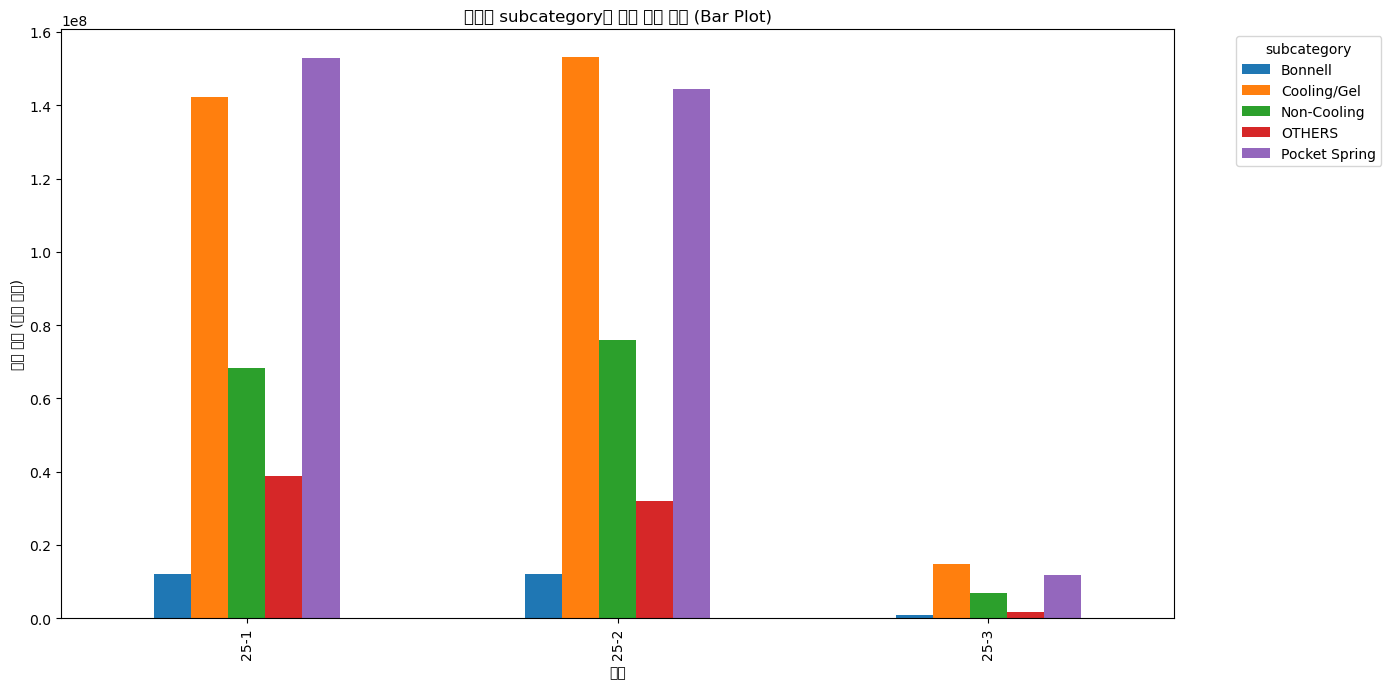

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\198039802.py:11: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\198039802.py:11: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\198039802.py:11: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\198039802.py:11: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\198039802.py:11: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\198039802.py:11: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu

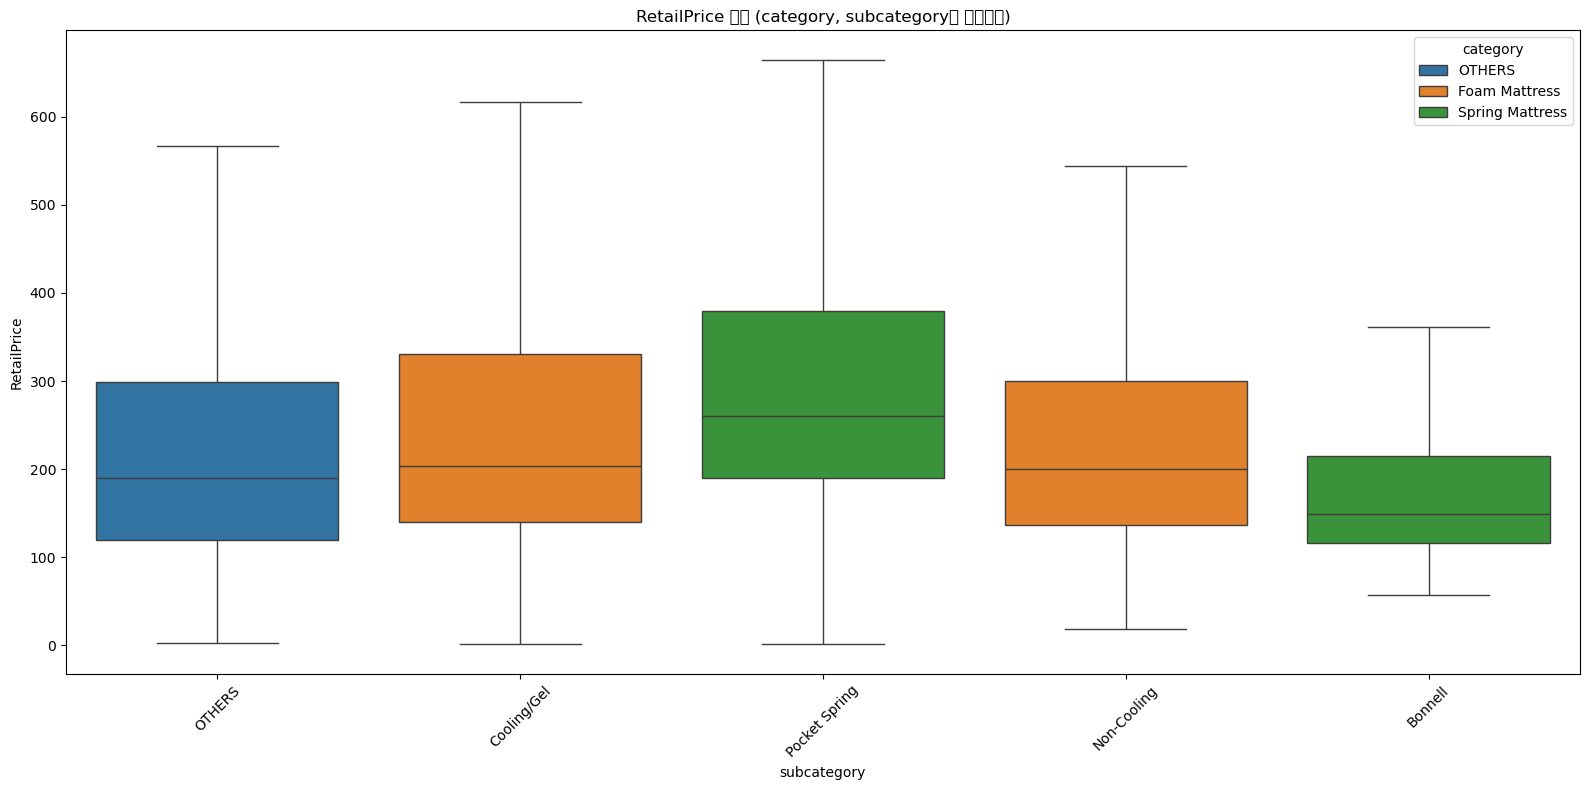

In [41]:

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df,
    x='subcategory',       # x축: subcategory
    y='RetailPrice',       # y축: 가격 컬럼
    hue='category',        # 색깔로 category 구분(선택적)
    showfliers=False       # 이상치 점을 안 그릴 경우
)
plt.xticks(rotation=45)
plt.title('RetailPrice 분포 (category, subcategory별 박스플롯)')
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\4242886939.py:13: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\4242886939.py:13: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_31616\4242886939.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserW

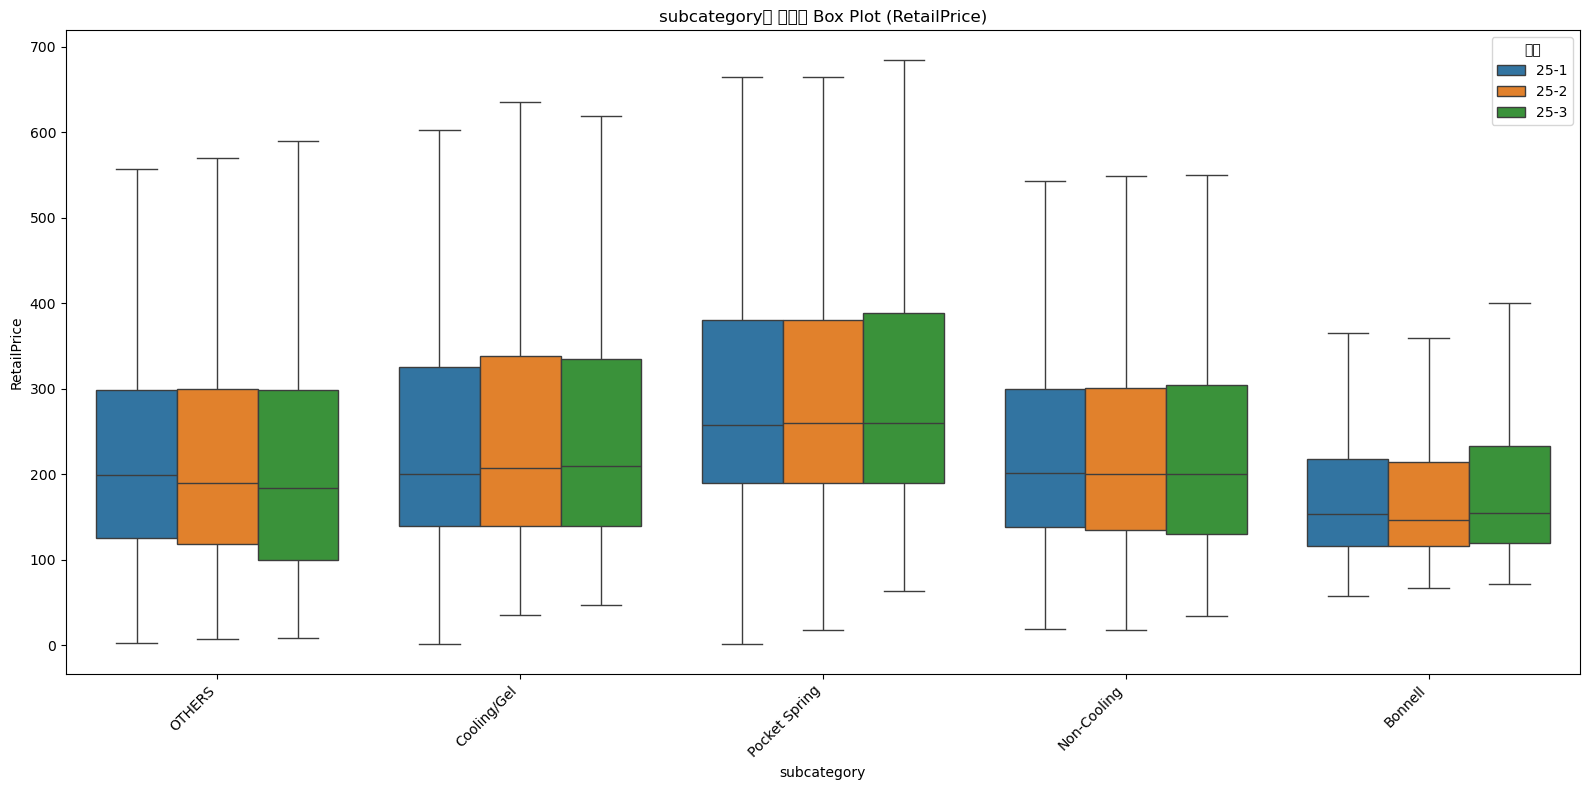

In [51]:

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df[df['RetailPrice'] > 0],  # 0 이하 제외 (로그변환 등에도 안전)
    x='subcategory',
    y='RetailPrice',
    hue='yr_quarter',        # 분기로 색 구분
    showfliers=False         # 이상치 점 표시 안함 (원하면 True로)
)

plt.xticks(rotation=45, ha='right')
plt.title('subcategory별 분기별 Box Plot (RetailPrice)')
plt.ylabel('RetailPrice')
plt.tight_layout()
plt.legend(title='분기')
plt.show()

#### 1.2 SKU별 매출합 구하기

In [78]:
sku_sales = df.groupby('RetailerSku')['RetailSales'].sum().sort_values(ascending=False).reset_index()

In [82]:
sku_sales['CumulSales'] = sku_sales['RetailSales'].cumsum()

In [84]:
sku_sales

,RetailerSku,RetailSales,CumulSales
0,B0BCYPWNWT,9339899.52,9.339900e+06
1,B0CKYZ3B83,9180964.57,1.852086e+07
2,B0CKZ1CK1H,7292219.03,2.581308e+07
3,B0DCXFXGBM,5885132.00,3.169822e+07
4,B0D7QW9612,5741208.39,3.743942e+07
...,...,...,...
10368,B0CDHBT64L,16.49,6.888918e+08
10369,B0DX7LG9M6,5.00,6.888918e+08
10370,B0DX7K6XQ2,3.00,6.888918e+08
10371,B0DX7JD1JS,2.00,6.888918e+08


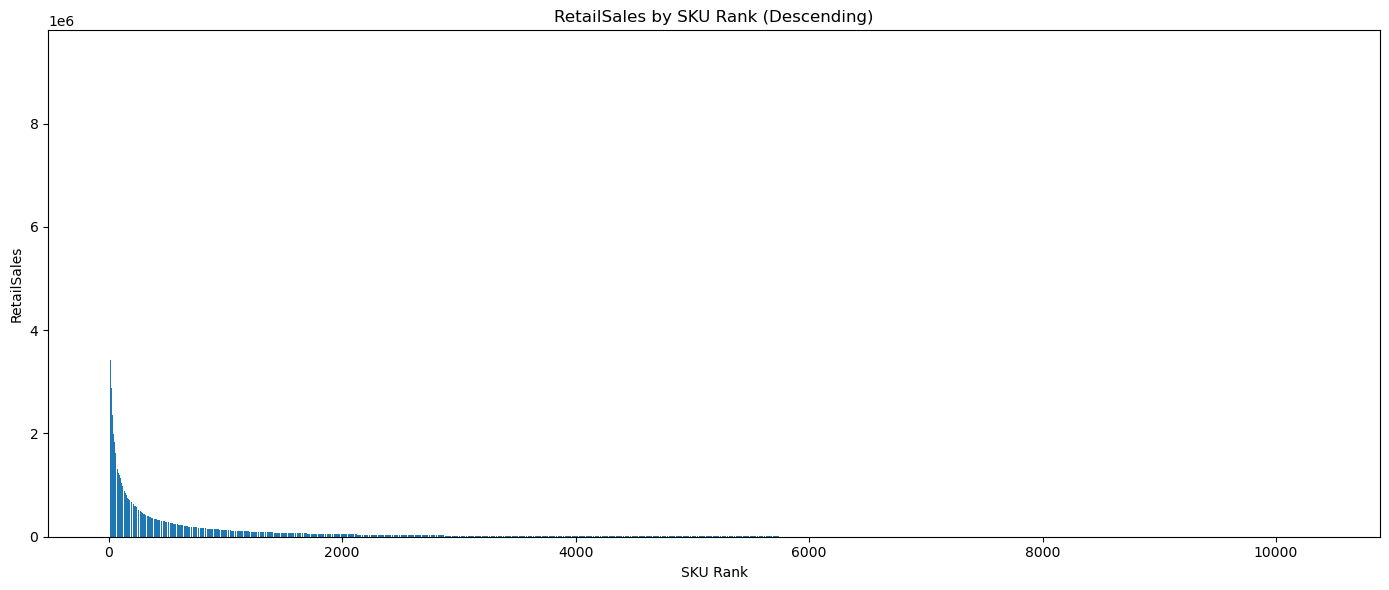

In [93]:
plt.figure(figsize=(14, 6))
plt.bar(np.arange(len(sku_sales)), sku_sales['RetailSales'])
plt.xlabel('SKU Rank')
plt.ylabel('RetailSales')
plt.title('RetailSales by SKU Rank (Descending)')
plt.tight_layout()
plt.show()

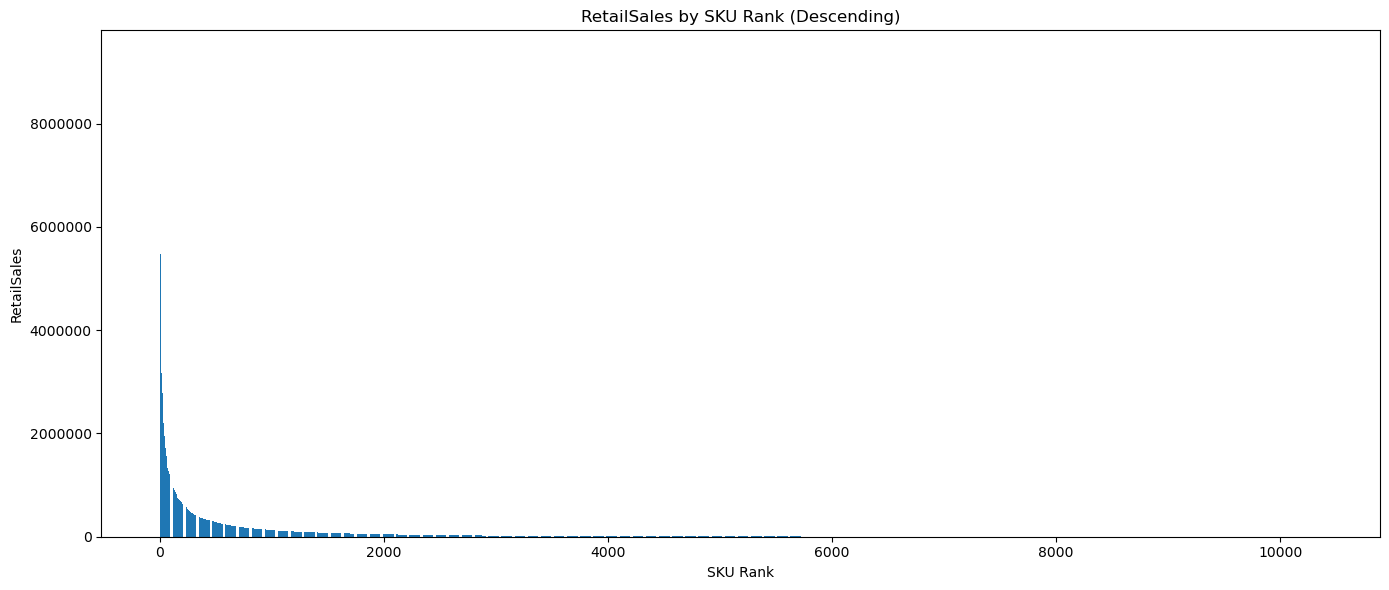

In [97]:
plt.figure(figsize=(14, 6))
plt.bar(np.arange(len(sku_sales)), sku_sales['RetailSales'])
plt.xlabel('SKU Rank')
plt.ylabel('RetailSales')
plt.title('RetailSales by SKU Rank (Descending)')

# Y축을 일반 숫자 표기로!
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
plt.ticklabel_format(style='plain', axis='y')  # Y축 표기 Plain Number

plt.tight_layout()
plt.show()

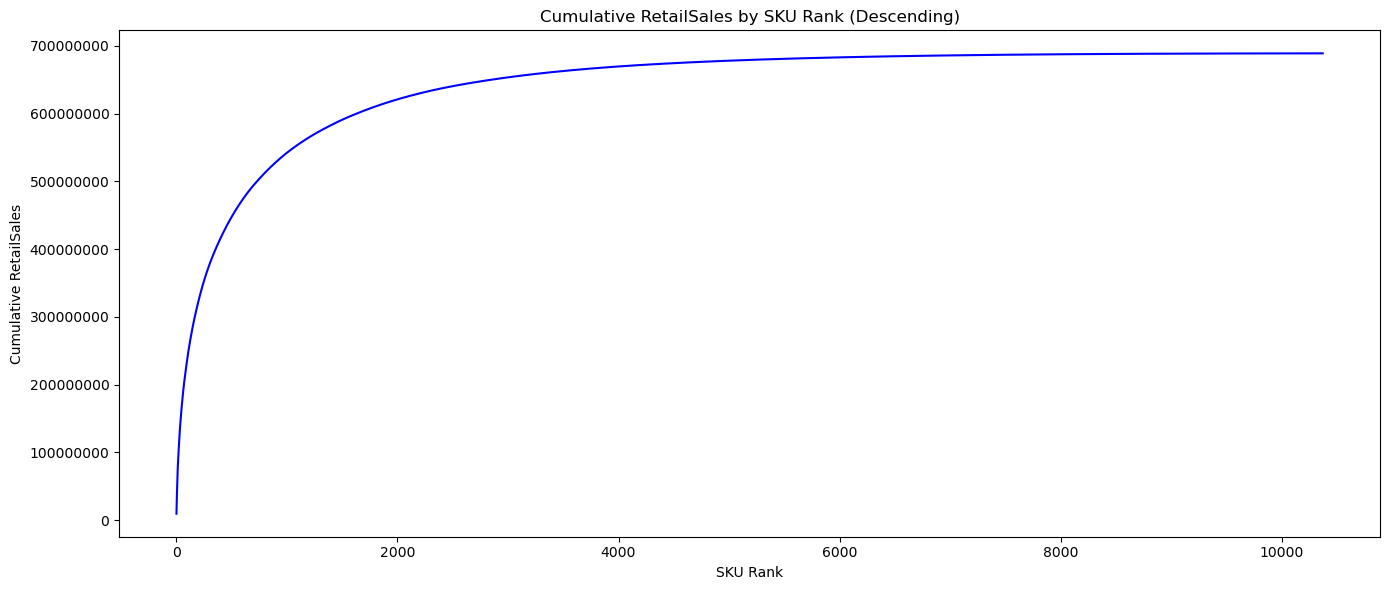

In [101]:
plt.figure(figsize=(14, 6))
plt.plot(np.arange(len(sku_sales)), sku_sales['CumulSales'], color='blue')
plt.xlabel('SKU Rank')
plt.ylabel('Cumulative RetailSales')
plt.title('Cumulative RetailSales by SKU Rank (Descending)')

# Y축 숫자 표기를 일반 표기로(지수 아님)
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

In [107]:
total_sales = sku_sales['RetailSales'].sum()
sku_sales['CumulSalesPercent'] = sku_sales['CumulSales'] / total_sales * 100

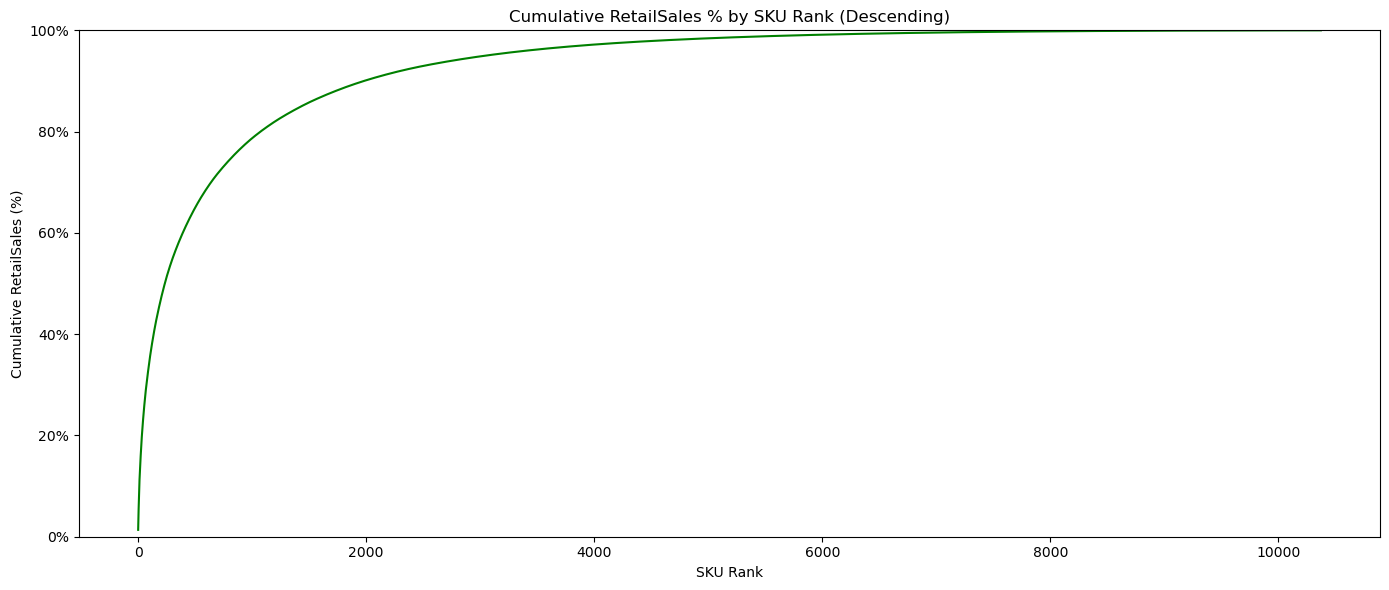

In [109]:
# 누적 매출 % 그래프
plt.figure(figsize=(14, 6))
plt.plot(np.arange(len(sku_sales)), sku_sales['CumulSalesPercent'], color='green')
plt.xlabel('SKU Rank')
plt.ylabel('Cumulative RetailSales (%)')
plt.title('Cumulative RetailSales % by SKU Rank (Descending)')

# Y축을 0~100%로 제한
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter())

plt.tight_layout()
plt.show()

In [89]:
# 5. 상위 80%를 차지하는 asin 리스트 추출
asin_top80 = asin_sales[asin_sales['cumrate'] <= 0.8]['asin'].tolist()
print(len(asin_top80))

113


In [91]:
df_top80 = df[df['asin'].isin(asin_top80)]
print(df_top80)

        crawl_date        asin  rating  ratings_total  salesrank1  salesrank2  \
51      2023-08-17  B09XM73Z65     4.5        78306.0      1009.0         2.0   
93      2023-08-17  B095W72PK1     4.5          253.0     52971.0        67.0   
144     2023-08-17  B075GW4GXH     4.6        19051.0      2932.0         3.0   
233     2023-08-17  B07DGHWVN8     4.6         2888.0      8718.0         1.0   
304     2023-08-17  B072HTRVM1     4.5        13738.0     26994.0       152.0   
...            ...         ...     ...            ...         ...         ...   
2636720 2025-06-16  B0CSJX57TM     4.4         5208.0         NaN         NaN   
2636735 2025-06-16  B0CKYYF9SJ     4.2        16430.0         NaN         NaN   
2636741 2025-06-16  B0CKYYHRN6     4.4        78245.0         NaN         NaN   
2636755 2025-06-16  B0CKYSMM1J     4.3        30283.0         NaN         NaN   
2636769 2025-06-16  B06WW43FVV     4.6        17182.0         NaN         NaN   

         salesrank3  bw_pri

In [93]:
df_top80['asin'].nunique()

113

In [109]:
# 해당 컬럼들 중 하나라도 NaN이면 제거
df_cleaned = df_top80.dropna(subset=['rating', 'ratings_total', 'bw_price', 'units', 'gv']).copy()
#df_cleaned = df_top80.rename(columns={'ratings_total': 'ratings_cnt'})
#df_cleaned = df_cleaned.rename(columns={'ratings_total': 'ratings_cnt'}, inplace=True)
print(df_cleaned)

        crawl_date        asin  rating  ratings_total  salesrank1  salesrank2  \
51      2023-08-17  B09XM73Z65     4.5        78306.0      1009.0         2.0   
93      2023-08-17  B095W72PK1     4.5          253.0     52971.0        67.0   
144     2023-08-17  B075GW4GXH     4.6        19051.0      2932.0         3.0   
233     2023-08-17  B07DGHWVN8     4.6         2888.0      8718.0         1.0   
304     2023-08-17  B072HTRVM1     4.5        13738.0     26994.0       152.0   
...            ...         ...     ...            ...         ...         ...   
2635790 2025-06-13  B0CKYYMG6F     4.4        78216.0       399.0         4.0   
2635807 2025-06-13  B0CSJTBM1L     4.4         9849.0       693.0         7.0   
2635842 2025-06-13  B0CSJX57TM     4.4         5200.0      3714.0        18.0   
2635853 2025-06-13  B089ZYJKBK     4.5         2106.0     40615.0       183.0   
2635855 2025-06-13  B0CKYZJY5T     4.2        16413.0      3420.0        16.0   

         salesrank3  bw_pri

In [111]:
df_cleaned.to_csv("0618_amz_pdp_price_sales_gv_top80_data.csv", index=False)